# Stroke Point Visualization: max_points_per_stroke Comparison

This notebook demonstrates the visual difference between using different values for `max_points_per_stroke` parameter from the config file.

Current config value: **100 points per stroke**  
Comparison value: **20 points per stroke**

We'll visualize the mathematical expression "O_{ij}" from the InkML file.

In [19]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import re

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12

In [20]:
def parse_inkml_file(file_path):
    """Parse InkML file and extract stroke data"""
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    # Get the namespace
    namespace = {'ink': 'http://www.w3.org/2003/InkML'}
    
    # Get label
    label_elem = root.find(".//ink:annotation[@type='label']", namespace)
    label = label_elem.text if label_elem is not None else "Unknown"
    
    # Get all traces (strokes)
    traces = root.findall(".//ink:trace", namespace)
    strokes = []
    
    for trace in traces:
        # Parse trace data: "x1 y1 t1,x2 y2 t2,..."
        points_str = trace.text.strip()
        points = []
        
        for point_str in points_str.split(','):
            coords = point_str.strip().split()
            if len(coords) >= 2:
                x, y = float(coords[0]), float(coords[1])
                points.append((x, y))
        
        if points:
            strokes.append(np.array(points))
    
    return label, strokes

# Load the InkML file
inkml_file = '000f8519b50a9e65.inkml'
label, original_strokes = parse_inkml_file(inkml_file)
print(f"Loaded expression: {label}")
print(f"Number of strokes: {len(original_strokes)}")
for i, stroke in enumerate(original_strokes):
    print(f"  Stroke {i}: {len(stroke)} points")

Loaded expression: v_i=C_i-V
Number of strokes: 10
  Stroke 0: 24 points
  Stroke 1: 13 points
  Stroke 2: 2 points
  Stroke 3: 22 points
  Stroke 4: 19 points
  Stroke 5: 24 points
  Stroke 6: 8 points
  Stroke 7: 2 points
  Stroke 8: 8 points
  Stroke 9: 36 points


In [21]:
def resample_stroke(stroke, target_points):
    """Resample a stroke to have exactly target_points points using interpolation"""
    if len(stroke) <= 1:
        return stroke
    
    # Calculate cumulative distance along the stroke
    distances = np.cumsum(np.sqrt(np.sum(np.diff(stroke, axis=0)**2, axis=1)))
    distances = np.insert(distances, 0, 0)  # Insert 0 at the beginning
    
    # Create interpolation functions for x and y coordinates
    fx = interpolate.interp1d(distances, stroke[:, 0], kind='linear')
    fy = interpolate.interp1d(distances, stroke[:, 1], kind='linear')
    
    # Create new equally-spaced points along the stroke
    new_distances = np.linspace(0, distances[-1], target_points)
    new_x = fx(new_distances)
    new_y = fy(new_distances)
    
    return np.column_stack([new_x, new_y])

def limit_stroke_points(strokes, max_points):
    """Limit each stroke to maximum number of points"""
    limited_strokes = []
    for stroke in strokes:
        if len(stroke) > max_points:
            # Resample to target number of points
            resampled = resample_stroke(stroke, max_points)
            limited_strokes.append(resampled)
        else:
            limited_strokes.append(stroke)
    return limited_strokes

# Create versions with different point limits
strokes_100 = limit_stroke_points(original_strokes, 100)
strokes_20 = limit_stroke_points(original_strokes, 10)

print("\nAfter resampling:")
print("With 100 max points per stroke:")
for i, stroke in enumerate(strokes_100):
    print(f"  Stroke {i}: {len(stroke)} points")

print("\nWith 10 max points per stroke:")
for i, stroke in enumerate(strokes_20):
    print(f"  Stroke {i}: {len(stroke)} points")


After resampling:
With 100 max points per stroke:
  Stroke 0: 24 points
  Stroke 1: 13 points
  Stroke 2: 2 points
  Stroke 3: 22 points
  Stroke 4: 19 points
  Stroke 5: 24 points
  Stroke 6: 8 points
  Stroke 7: 2 points
  Stroke 8: 8 points
  Stroke 9: 36 points

With 10 max points per stroke:
  Stroke 0: 10 points
  Stroke 1: 10 points
  Stroke 2: 2 points
  Stroke 3: 10 points
  Stroke 4: 10 points
  Stroke 5: 10 points
  Stroke 6: 8 points
  Stroke 7: 2 points
  Stroke 8: 8 points
  Stroke 9: 10 points


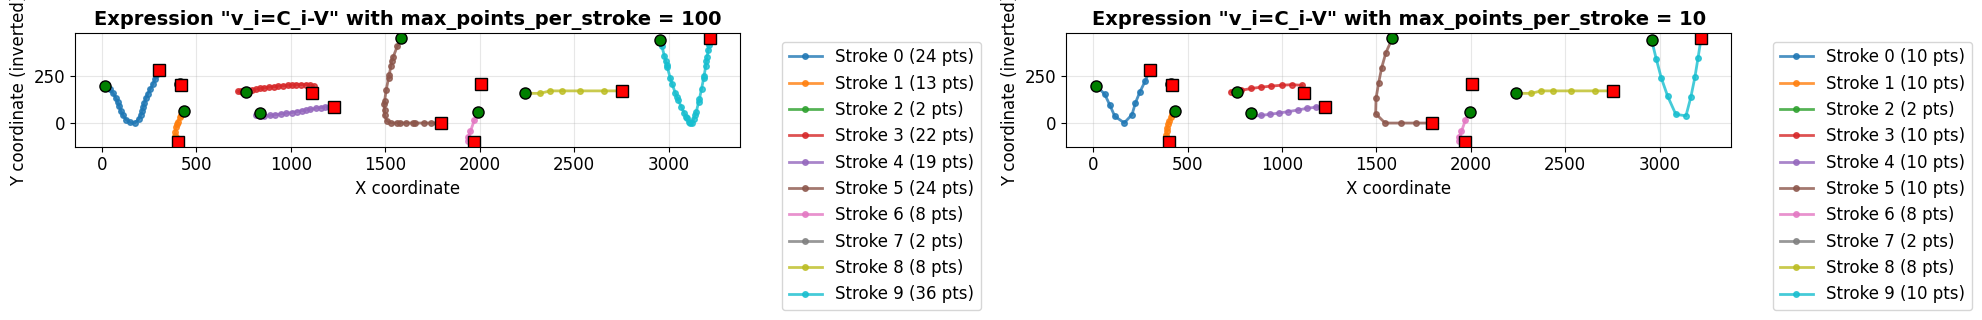


Legend:
🟢 Green circles: Start points of each stroke
🟥 Red squares: End points of each stroke
Lines with circles: Individual points along each stroke


In [22]:
def plot_strokes(strokes, title, ax, colors=None):
    """Plot strokes on given axis"""
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(strokes)))
    
    for i, stroke in enumerate(strokes):
        if len(stroke) > 0:
            # Plot the stroke line
            ax.plot(stroke[:, 0], -stroke[:, 1], 'o-', 
                   color=colors[i], linewidth=2, markersize=4, 
                   label=f'Stroke {i} ({len(stroke)} pts)',
                   alpha=0.8)
            
            # Mark start point
            ax.plot(stroke[0, 0], -stroke[0, 1], 'o', 
                   color='green', markersize=8, markeredgecolor='black')
            
            # Mark end point
            ax.plot(stroke[-1, 0], -stroke[-1, 1], 's', 
                   color='red', markersize=8, markeredgecolor='black')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate (inverted)')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_aspect('equal')

# Create the comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Same colors for both plots to make comparison easier
colors = plt.cm.tab10(np.linspace(0, 1, len(original_strokes)))

plot_strokes(strokes_100, f'Expression \"{label}\" with max_points_per_stroke = 100', ax1, colors)
plot_strokes(strokes_20, f'Expression \"{label}\" with max_points_per_stroke = 10', ax2, colors)

plt.tight_layout()
plt.show()

# Add legend explanation
print("\nLegend:")
print("🟢 Green circles: Start points of each stroke")
print("🟥 Red squares: End points of each stroke")
print("Lines with circles: Individual points along each stroke")

In [23]:
# Statistical comparison
print("\n" + "="*60)
print("STATISTICAL COMPARISON")
print("="*60)

total_points_original = sum(len(stroke) for stroke in original_strokes)
total_points_100 = sum(len(stroke) for stroke in strokes_100)
total_points_20 = sum(len(stroke) for stroke in strokes_20)

print(f"Original total points: {total_points_original}")
print(f"With max_points_per_stroke=100: {total_points_100} points ({total_points_100/total_points_original*100:.1f}% of original)")
print(f"With max_points_per_stroke=20: {total_points_20} points ({total_points_20/total_points_original*100:.1f}% of original)")

print(f"\nData reduction:")
print(f"100 vs Original: {(1-total_points_100/total_points_original)*100:.1f}% reduction")
print(f"20 vs Original: {(1-total_points_20/total_points_original)*100:.1f}% reduction")
print(f"20 vs 100: {(1-total_points_20/total_points_100)*100:.1f}% additional reduction")


STATISTICAL COMPARISON
Original total points: 158
With max_points_per_stroke=100: 158 points (100.0% of original)
With max_points_per_stroke=20: 80 points (50.6% of original)

Data reduction:
100 vs Original: 0.0% reduction
20 vs Original: 49.4% reduction
20 vs 100: 49.4% additional reduction


In [ ]:
# Detail comparison for each stroke
print("\n" + "="*60)
print("PER-STROKE ANALYSIS")
print("="*60)
S
for i in range(len(original_strokes)):
    orig_len = len(original_strokes[i])
    len_100 = len(strokes_100[i])
    len_20 = len(strokes_20[i])
    
    print(f"\nStroke {i}:")
    print(f"  Original: {orig_len} points")
    print(f"  Max 100:  {len_100} points {'(limited)' if len_100 < orig_len else '(unchanged)'}")
    print(f"  Max 10:   {len_20} points {'(limited)' if len_20 < orig_len else '(unchanged)'}")
    
    if orig_len > 100:
        print(f"  → 100pt version: {(1-len_100/orig_len)*100:.1f}% point reduction")
    if orig_len > 20:
        print(f"  → 10pt version: {(1-len_20/orig_len)*100:.1f}% point reduction")


PER-STROKE ANALYSIS

Stroke 0:
  Original: 24 points
  Max 100:  24 points (unchanged)
  Max 10:   10 points (limited)
  → 10pt version: 58.3% point reduction

Stroke 1:
  Original: 13 points
  Max 100:  13 points (unchanged)
  Max 10:   10 points (limited)

Stroke 2:
  Original: 2 points
  Max 100:  2 points (unchanged)
  Max 10:   2 points (unchanged)

Stroke 3:
  Original: 22 points
  Max 100:  22 points (unchanged)
  Max 10:   10 points (limited)
  → 10pt version: 54.5% point reduction

Stroke 4:
  Original: 19 points
  Max 100:  19 points (unchanged)
  Max 10:   10 points (limited)

Stroke 5:
  Original: 24 points
  Max 100:  24 points (unchanged)
  Max 10:   10 points (limited)
  → 10pt version: 58.3% point reduction

Stroke 6:
  Original: 8 points
  Max 100:  8 points (unchanged)
  Max 10:   8 points (unchanged)

Stroke 7:
  Original: 2 points
  Max 100:  2 points (unchanged)
  Max 10:   2 points (unchanged)

Stroke 8:
  Original: 8 points
  Max 100:  8 points (unchanged)
  Max

## Analysis Summary

This visualization demonstrates the trade-off when changing the `max_points_per_stroke` parameter:

### Key Observations:

1. **Detail Preservation**: Higher `max_points_per_stroke` (100) preserves more fine details in the handwritten strokes
2. **Memory Efficiency**: Lower `max_points_per_stroke` (20) significantly reduces memory usage and computational load
3. **Shape Integrity**: Even with fewer points, the overall shape and structure of the mathematical expression is maintained
4. **Processing Speed**: Fewer points per stroke means faster training and inference

### Recommendations:

- **For high accuracy**: Use `max_points_per_stroke: 100` when detail preservation is critical
- **For fast training**: Use `max_points_per_stroke: 20-50` for development and quick experiments
- **For production**: Consider testing different values to find the optimal balance between accuracy and efficiency

The current config uses 100 points per stroke, which provides good detail preservation while still being manageable for training.